First 5 Rows:
   YearsExperience   Salary
0              1.1  39343.0
1              1.3  46205.0
2              1.5  37731.0
3              2.0  43525.0
4              2.2  39891.0

Last 5 Rows:
    YearsExperience    Salary
25              9.0  105582.0
26              9.5  116969.0
27              9.6  112635.0
28             10.3  122391.0
29             10.5  121872.0

Shape: (30, 2)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes

Descriptive Statistics:
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%          

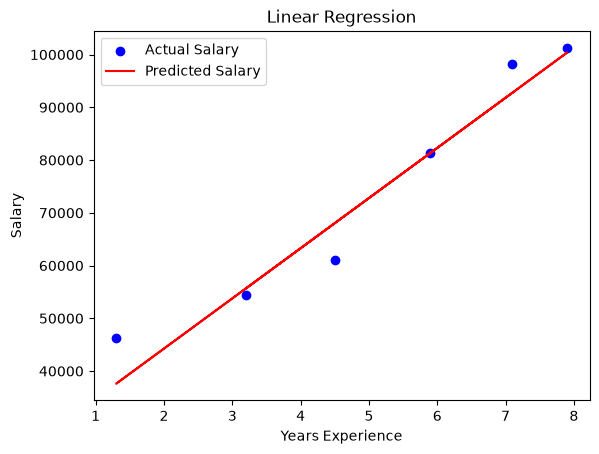

In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Load Dataset
df = pd.read_csv("Salary_Data.csv")

print("First 5 Rows:")
print(df.head())

print("\nLast 5 Rows:")
print(df.tail())

# 2. Initial Data Analysis
print("\nShape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nDescriptive Statistics:")
print(df.describe())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nNumerical Columns:")
print(df.select_dtypes(include=np.number).columns)

print("\nCategorical Columns:")
print(df.select_dtypes(include='object').columns)


df = df.drop_duplicates()


for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())



columnname = 'Salary'

Q1 = df[columnname].quantile(0.25)
Q3 = df[columnname].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("\nQ1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)


outliers = df[
    (df[columnname] < lower) |
    (df[columnname] > upper)
]

print("\nOutliers:")
print(outliers)

print("Number of Outliers:", len(outliers))


df = df[
    (df[columnname] >= lower) &
    (df[columnname] <= upper)
].copy()

print("\nData After Removing Outliers:")
print(df.shape)



X = df[['YearsExperience']]
y = df['Salary']

print("\nIndependent Variable (X):")
print(X)

print("\nDependent Variable (y):")
print(y)

# 6. Train-Test Split (80:20)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=12
)

print("\nTraining Data:", X_train.shape)
print("Testing Data:", X_test.shape)

# 7. Linear Regression Model

model = LinearRegression()

model.fit(X_train, y_train)

print("\nCoefficient:", model.coef_[0])
print("Intercept:", model.intercept_)

# 8. Prediction

y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

# 9. Model Evaluation

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = np.sqrt(MSE)
R2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print("MAE:", MAE)
print("MSE:", MSE)
print("RMSE:", RMSE)
print("R2 Score:", R2)

# 10. Actual vs Predicted Values

result = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': y_pred
})

print("\nActual vs Predicted:")
print(result)

# 11. Visualization

plt.scatter(X_test, y_test, color='blue', label='Actual Salary')
plt.plot(X_test, y_pred, color='red', label='Predicted Salary')

plt.xlabel("Years Experience")
plt.ylabel("Salary")
plt.title("Linear Regression")
plt.legend()
plt.show()